# TP1 — From Theory to Practice: MLP with PyTorch

---

## Objectives

By the end of this session, you will be able to:
1. Manipulate **PyTorch tensors and automatic differentiation** as the computational substrate of deep learning
2. Implement a **complete supervised training pipeline** from data loading to evaluation
3. Design and interpret **controlled experiments** comparing optimisation strategies and regularisation techniques

## Prerequisites (CM1–CM2)
- **CM1**: MLP architecture, activation functions, backpropagation, vanishing/exploding gradients
- **CM2**: PyTorch training pipeline — DataLoader, nn.Module, optimisers, Dropout, Batch Normalisation

## Deliverables
**Send your GitHub repository link to [xchang3@slb.com](mailto:xchang3@slb.com) and submit on GitHub before the deadline.**
```
your-repo/
├── tp1-pytorch-mlp.ipynb   ← all cells executed top-to-bottom, outputs visible
└── report.pdf              ← 1–2 pages, maximum 2 pages
```

**Deadline**: **23:59, September 24th**

This TP is completed in pairs (binôme). Submit one GitHub repository per pair.

Your PDF report should answer the following sections:
1. **Part 1 — Baseline Model**: answer the four questions at the end of Part 1
2. **Experiment 1**: fill in the Results and Analysis section
3. **Experiment 2A**: fill in the Results and Analysis section
4. **Experiment 2B**: fill in the Results and Analysis section
5. **Experiment 3**: fill in the Results and Analysis section

Results must be discussed analytically — cite specific numbers, reference figures by their titles, and connect observations to theory from CM1/CM2.

## Session Structure

| Part | Content |
|------|---------|
| 0 · Tensor Warmup | Core tensor operations and automatic differentiation |
| 1 · Training Pipeline | End-to-end MLP implementation on Fashion-MNIST |
| 2 · Experimental Analysis | Student-designed ablation studies |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ── Device setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'PyTorch version: {torch.__version__}')

# num_workers: multiprocessing helps on GPU; set to 0 on CPU to avoid fork issues
NUM_WORKERS = 2 if device.type == 'cuda' else 0

Using device: cpu
PyTorch version: 2.14.0


---
## Part 0 — Tensor Warmup

This section introduces PyTorch's core primitives — tensors and automatic differentiation — which underpin every operation in a deep learning pipeline.

### Exercise 0.1 — Tensor Operations

A neural network forward pass is a composition of matrix multiplications and element-wise non-linearities. The following exercise traces one such step explicitly in PyTorch. Complete the `# TODO` sections.

In [2]:
# (a) A mini-batch of 4 28×28 images, each flattened to 784 pixels
batch = torch.zeros(4, 784)
print(f'Batch shape: {batch.shape}')

# (b) Weight matrix for a Linear layer: 784 inputs → 128 outputs
# TODO: Create a random weight matrix W using torch.randn with the correct shape, shape: (out_features, in_features)
W = torch.randn(128, 784)

# (c) Linear transformation (4, 784) * (784, 128) → (4, 128)
# TODO: Compute the matrix product — result should have shape [4, 128]
output = batch @ W.T
if output is not None:
    print(f'Linear output shape: {output.shape}')  # Expected: torch.Size([4, 128])

# (d) Apply ReLU activation  (recall CM1: why ReLU instead of Sigmoid?)
# TODO: Apply F.relu() to output
activated = F.relu(output)
if activated is not None:
    print(f'After ReLU — min value : {activated.min():.3f}')  # Must be 0.0
    print(f'           — #negatives: {(activated < 0).sum().item()}')  # Must be 0

Batch shape: torch.Size([4, 784])
Linear output shape: torch.Size([4, 128])
After ReLU — min value : 0.000
           — #negatives: 0


### Exercise 0.2 — Automatic Differentiation

PyTorch implements reverse-mode automatic differentiation through a dynamically constructed computation graph. This mirrors the backpropagation derivation, but is executed automatically by the framework.

**Before running the following cell**, derive $\frac{dL}{dw}$ analytically:

$$L = (wx - y)^2, \quad x = 2,\; y = 3,\; w = 1$$

$$\frac{dL}{dw} = 2(wx - y) \cdot x = ?$$

Record your result, then verify against PyTorch's computed gradient.

Complete the `# TODO` sections.

In [3]:
x = torch.tensor(2.0)
y = torch.tensor(3.0)
w = torch.tensor(1.0, requires_grad=True)  # requires_grad=True: PyTorch will track this

# Forward pass
pred = w * x            # = 2.0
loss = (pred - y) ** 2  # = (2 - 3)^2 = 1.0

print(f'Prediction: {pred.item():.1f}')
print(f'Loss:       {loss.item():.1f}')

# Write your manual answer before running the next cell
my_gradient = 2 * (1 * 2 - 3) * 2
if my_gradient is not None:
    print(f'My manual dL/dw: {my_gradient}')

Prediction: 2.0
Loss:       1.0
My manual dL/dw: -4


In [4]:
# PyTorch computes the gradient via reverse-mode autodiff
# call loss.backward() to trigger the backward pass
loss.backward()
print(f'Analytical dL/dw:  {my_gradient}')
print(f'PyTorch  dL/dw:    {w.grad.item():.1f}')

# One gradient-descent update (lr = 0.1)
# Compute new_w = w - lr * gradient (use w.grad, lr = 0.1)
lr = 0.1
new_w = w.item() - lr * w.grad.item()
print(f'Gradient step (lr=0.1): w = {w.item():.1f} -> {new_w:.2f}')
print(f'Updated prediction: {new_w * x.item():.2f}   (target: {y.item():.1f})')

Analytical dL/dw:  -4
PyTorch  dL/dw:    -4.0
Gradient step (lr=0.1): w = 1.0 -> 1.40
Updated prediction: 2.80   (target: 3.0)


---
## Part 1 — Training Pipeline

In this section, we will implement manually a complete MLP training pipeline step by step on Fashion-MNIST, following the five-step framework introduced in CM2:

**Data Preparation → Model Architecture → Training → Diagnosis → Regularisation**

Complete the `# TODO` sections. All other code is provided; study each block before executing it.

### 1.1 — Dataset and Task

**What we're building**: a classifier that reads a 28×28 grayscale image of a clothing item and predicts which of 10 categories it belongs to.

#### The Dataset: Fashion-MNIST

Fashion-MNIST was created by Zalando Research as a drop-in replacement for the classic MNIST digit dataset. While MNIST (handwritten digits) has become too easy for modern models, Fashion-MNIST poses a more realistic challenge: clothing categories share visual structure (e.g. T-shirts and shirts look similar), making classification harder. It has become a standard benchmark for evaluating simple architectures.

| Property | Value |
|----------|-------|
| Image size | 28×28 pixels, grayscale |
| Input dimension | **784 features** (after flattening) |
| Classes | 10 clothing categories |
| Train set | 60,000 images |
| Test set | 10,000 images |
| Our split | 48,000 train / 12,000 val / 10,000 test |

The 10 classes: `T-shirt/top · Trouser · Pullover · Dress · Coat · Sandal · Shirt · Sneaker · Bag · Ankle boot`


In [5]:
# ── 1.1  Load Fashion-MNIST ───────────────────────────────────────────────────

FASHION_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

# Preprocessing pipeline applied to every image:
#   ToTensor()   — converts PIL image [0,255] to float tensor [0,1], shape (1,28,28)
#   Normalize()  — standardises to zero mean and unit variance (channel-wise)
#                  values: mean=0.2860, std=0.3530 (pre-computed for Fashion-MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Download the dataset (first run only; cached to ./data afterwards)
full_train = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split the 60k training set into 80% train / 20% validation.
# The validation set monitors generalisation during training;
# In a standard DL workflow, the test set is reserved for final evaluation. In this TP, test accuracy is also displayed for pedagogical comparison.
n_val = int(0.2 * len(full_train))
train_set, val_set = random_split(
    full_train, [len(full_train) - n_val, n_val],
    generator=torch.Generator().manual_seed(42)  # fixed seed → reproducible split
)

# DataLoader handles batching, shuffling, and parallel data loading.
#   batch_size  — number of samples per gradient update
#   shuffle     — randomise order each epoch (training only)
#   num_workers — background processes for loading (0 on CPU to avoid fork issues)
#   pin_memory  — speeds up CPU→GPU transfer when a GPU is available
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}')

images, labels = next(iter(train_loader))
print(f'Batch  — images: {images.shape}  labels: {labels.shape}')
print(f'Single image shape: {images[0].shape}  =>  flattened: {images[0].numel()} features')

Train: 48,000 | Val: 12,000 | Test: 10,000
Batch  — images: torch.Size([64, 1, 28, 28])  labels: torch.Size([64])
Single image shape: torch.Size([1, 28, 28])  =>  flattened: 784 features


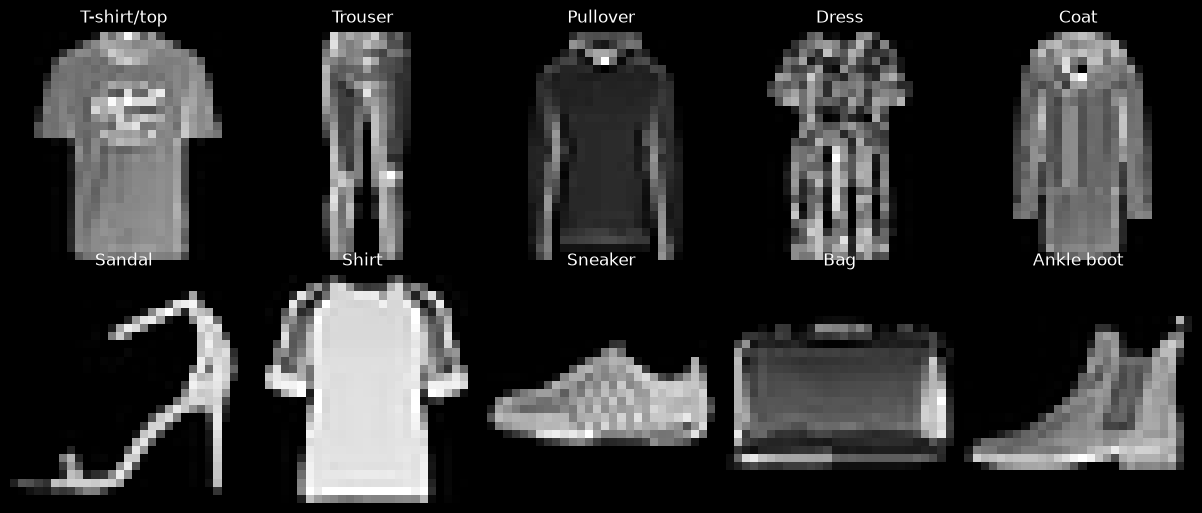

In [6]:
# Collect one representative image per class from the training set.
# We iterate through batches until we have found at least one example of each of the 10 classes.
_samples = {}
for _imgs, _lbls in train_loader:
    for _img, _lbl in zip(_imgs, _lbls):
        lbl = _lbl.item()
        if lbl not in _samples:
            # Un-normalise for display: reverse Normalize(mean, std) → pixel values in [0,1]
            _samples[lbl] = (_img.squeeze().numpy() * 0.353 + 0.286).clip(0, 1)
        if len(_samples) == 10:
            break
    if len(_samples) == 10:
        break

# Display the 10 classes in a 2×5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.patch.set_facecolor('black')
for i, ax in enumerate(axes.flat):
    ax.imshow(_samples[i], cmap='gray')
    ax.set_title(FASHION_CLASSES[i], color='white', fontsize=12, pad=7)
    ax.axis('off')
    ax.set_facecolor('black')
plt.tight_layout(pad=0.5)
plt.show()

del _samples, _imgs, _lbls, _img, _lbl  # free memory

### 1.2 — Model Architecture

The architecture you will implement:

```
Input (784)  →  Hidden 1 (256, ReLU)  →  Hidden 2 (128, ReLU)  →  Output (10 logits)
```

The `hidden_sizes` parameter controls depth — `[256, 128]` gives 2 hidden layers, `[512, 256, 128]` gives 3. This flexibility is used throughout Part 2.

Each hidden block follows this standard ordering (CM2):

```
nn.Linear  →  [nn.BatchNorm1d]  →  nn.ReLU  →  [nn.Dropout]
```

**What you need to do** (complete the `# TODO` lines in the cell below):
1. Inside the `for` loop — for each hidden layer:
   - Add a `nn.Linear` layer
   - Add `nn.BatchNorm1d` if `use_batchnorm` is True
   - Add the activation function
   - Add `nn.Dropout` if `dropout_rate > 0`
   - Update `in_dim` for the next iteration
2. After the loop — add the output projection `nn.Linear(???, ???)`

> `forward()` is already implemented — `x.view` flattens the image, then `self.net` runs the full pipeline.

In [7]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[256, 128], dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        in_dim = 784 #input layer dimension

        for h in hidden_sizes: # h is hideen layer size
            # TODO: Add linear layer. Use nn.Linear(in_features, out_features)
            layers.append(nn.Linear(in_dim, h))

            if use_batchnorm:
                # TODO: Add Batch Normalization. nn.BatchNorm1d normalises each feature independently using statistics computed across the mini-batch. How many features does the preceding Linear layer output?
                layers.append(nn.BatchNorm1d(h))

            # TODO: Add activation function. (CM1: what property makes it suitable for deep ReLU networks?)
            layers.append(nn.ReLU())
                          
            if dropout_rate > 0:
                # TODO: Add Dropout layer. Dropout takes a probability p in [0, 1]
                layers.append(nn.Dropout(dropout_rate))

            # TODO: after this block, the feature dimension has changed, update in_dim so the next iteration uses the correct input size
            in_dim = h

        # ── Output: no activation (CrossEntropyLoss handles softmax internally) ──
        # TODO: For Output layer, the input dimension is whatever came out of the last hidden block
        #                         the output dimension must match the number of classes in Fashion-MNIST
        layers.append(nn.Linear(in_dim, 10))

        # nn.Sequential wraps the layer list into a single callable module.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten the 2D image into a 1D feature vector before passing through the layers
        x = x.view(x.size(0), -1)   # (batch, 1, 28, 28) → (batch, 784)

        # When called with self.net(x), it passes x through each layer in order. 
        # PyTorch also uses self.net to automatically track all parameters.
        logits = self.net(x)         # raw class scores — shape (batch_size, 10)
        
        return logits

In [8]:
# ── Sanity check ──────────────────────────────────────────────────────────────
# Run this cell to verify your MLP is correctly built before training.

# Instantiate the model and move it to the compute device (GPU if available)
model = MLP(hidden_sizes=[256, 128]).to(device)

# Count trainable parameters — a quick way to verify the architecture size
# For MLP([256, 128]), parameters come from 3 Linear layers:
#   784 × 256 + 256 (bias) = 200,960
#   256 × 128 + 128        =  32,896
#   128 × 10  + 10         =   1,290
#   Total                  = 235,146
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture     : 784 → 256 → 128 → 10')
print(f'Total Parameters : {n_params:,}')
print(model.net)  # prints each layer in order

# Test the forward pass with a dummy batch of 4 images
# Output shape must be (batch_size, n_classes) = (4, 10)
dummy = torch.randn(4, 1, 28, 28).to(device)
out = model(dummy)
if out is not None:
    print(f'\nInput: {dummy.shape}  =>  Output: {out.shape}')  # expected: torch.Size([4, 10])
else:
    print('forward() returned None — check your TODO in forward()')

Architecture     : 784 → 256 → 128 → 10
Total Parameters : 235,146
Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Input: torch.Size([4, 1, 28, 28])  =>  Output: torch.Size([4, 10])


### 1.3 — Loss Function and Optimiser

Select the appropriate loss function and baseline optimiser. Each choice should be justified on the basis of the theoretical arguments from CM1 and CM2.

In [9]:
# Q1: Which loss function is correct for 10-class classification?
#     Options: nn.CrossEntropyLoss()  or  nn.MSELoss()
criterion = nn.CrossEntropyLoss()

# Q2: Baseline optimizer — Adam with lr=1e-3, no regularisation
#     (from CM2: optim.Adam(model.parameters(), lr=..., weight_decay=...))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)

if criterion is not None and optimizer is not None:
    lr = optimizer.param_groups[0]['lr']
    wd = optimizer.param_groups[0]['weight_decay']
    print(f'Loss     : {type(criterion).__name__}')
    print(f'Optimizer: {type(optimizer).__name__}, lr={lr}, weight_decay={wd}')

Loss     : CrossEntropyLoss
Optimizer: Adam, lr=0.001, weight_decay=0


### 1.4 — Training Loop

The functions below implement the standard supervised training loop. Study the implementation — in particular the role of `model.train()` / `model.eval()` and `torch.no_grad()` — before executing. These functions are reused throughout Part 2.

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    '''One epoch of training. Returns (avg_loss, accuracy).'''
    model.train()
    # sets training mode (only takes effect if those layers are present):
    #   - Dropout randomly zeros activations with probability p — prevents co-adaptation
    #   - BatchNorm uses batch statistics for normalisation AND accumulates running stats:
    #       batch_mean   = mean(x_batch)                           ← normalises the current batch
    #       running_mean = 0.9 * running_mean + 0.1 * batch_mean   ← updated simultaneously
    total_loss, correct, total = 0.0, 0, 0  # accumulators for the whole epoch

    for images, labels in loader:  # iterate over mini-batches
        images, labels = images.to(device), labels.to(device)  # move data to GPU/CPU

        optimizer.zero_grad()              # 1. clear gradients from the previous step (PyTorch accumulates gradients by default)
        outputs = model(images)            # 2. forward pass → logits of shape (batch, 10)
        loss = criterion(outputs, labels)  # 3. compute scalar loss for this batch
        loss.backward()                    # 4. backprop: compute dL/dw for every parameter
        optimizer.step()                   # 5. update weights: for plain SGD，it's w ← w - lr * dL/dw

        # Accumulate stats — weight by batch size because the last batch may be smaller
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)  # index of the highest logit = predicted class
        correct += predicted.eq(labels).sum().item()  # count correct predictions
        total   += images.size(0)

    return total_loss / total, correct / total  # average loss and accuracy over the epoch



def evaluate(model, loader, criterion):
    total_loss, correct, total = 0.0, 0, 0
    '''Evaluate on a data loader. Returns (avg_loss, accuracy).'''

    model.eval()
    # sets evaluation mode:
    #   - Dropout is disabled (all neurons are active, no random dropping)
    #   - BatchNorm switches from batch statistics to running statistics:
    #       During training, BatchNorm computes mean/var from each batch AND
    #       accumulates a running_mean/running_var via exponential moving average.
    #       During eval, it uses these accumulated values instead of the current batch —
    #       more stable, especially when batch_size is small or equals 1.

    with torch.no_grad():  # disable gradient computation — faster and uses less memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)  # move data to GPU/CPU
            outputs = model(images)            # forward pass — no gradient tracked
            loss = criterion(outputs, labels)  # compute loss for this batch

            # Same accumulation logic as train_epoch
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)  # predicted class = index of highest logit
            correct += predicted.eq(labels).sum().item()
            total   += images.size(0)

    return total_loss / total, correct / total

In [11]:
# ── Train your baseline model ─────────────────────────────────────────────────
NUM_EPOCHS = 15
baseline_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc')
print('-' * 54)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    baseline_history['train_loss'].append(tr_loss)
    baseline_history['val_loss'].append(va_loss)
    baseline_history['train_acc'].append(tr_acc)
    baseline_history['val_acc'].append(va_acc)

    print(f'{epoch:>5} | {tr_loss:>10.4f} | {va_loss:>8.4f} | {tr_acc:>9.2%} | {va_acc:>7.2%}')

test_loss, test_acc = evaluate(model, test_loader, criterion)
print()
print(f'Baseline Test Accuracy: {test_acc:.2%}')

Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc
------------------------------------------------------


    1 |     0.4787 |   0.3848 |    82.56% |  86.33%


    2 |     0.3538 |   0.3762 |    86.84% |  86.74%


    3 |     0.3125 |   0.3390 |    88.29% |  87.78%


    4 |     0.2901 |   0.3235 |    89.19% |  88.08%


...

   12 |     0.1764 |   0.3465 |    93.28% |  89.02%


   13 |     0.1727 |   0.3630 |    93.50% |  89.19%


   14 |     0.1634 |   0.3804 |    93.71% |  88.35%


   15 |     0.1575 |   0.3683 |    93.96% |  88.88%



Baseline Test Accuracy: 88.39%


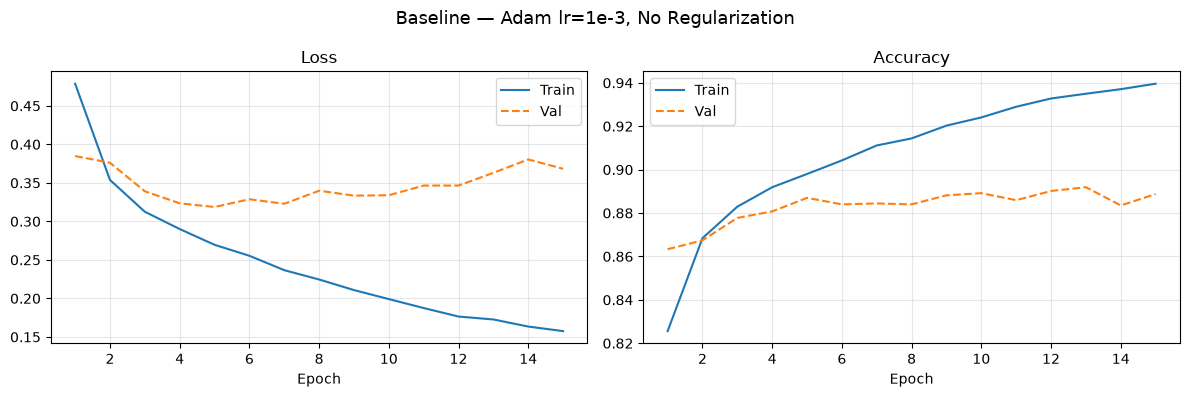

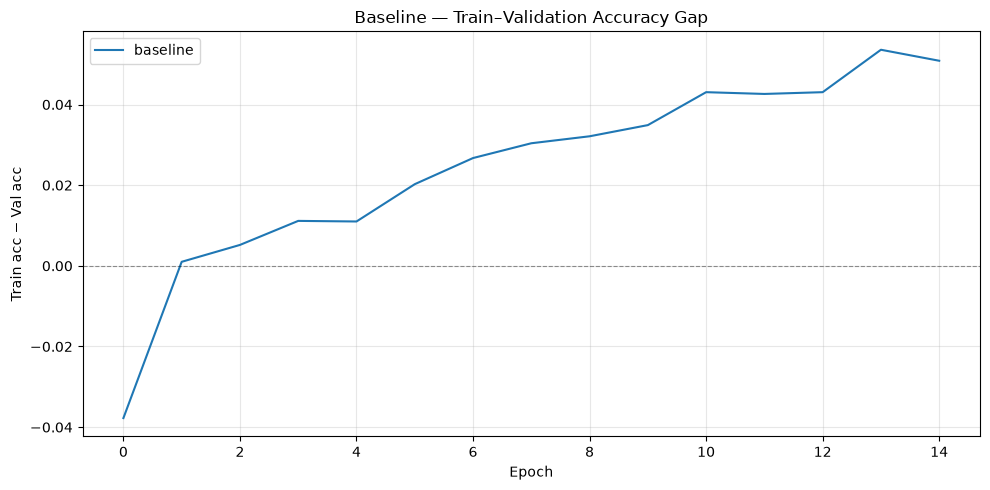

In [12]:
def plot_history(history, title='Training Curves'):
    '''Plot loss and accuracy curves from a history dict.'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val', linestyle='--')
    ax1.set_title('Loss');     ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val', linestyle='--')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_gap(results, title='Train–Validation Accuracy Gap'):
    '''
    Plot the train-val accuracy gap (train_acc - val_acc) per epoch.
    '''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        gap = [t - v for t, v in zip(hist['train_acc'], hist['val_acc'])]
        plt.plot(gap, label=label)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)  # zero-gap reference line
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Train acc − Val acc')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_history(baseline_history, title='Baseline — Adam lr=1e-3, No Regularization')
plot_gap({'baseline': baseline_history}, title='Baseline — Train–Validation Accuracy Gap')

**Section 1 of your report** is based on what you just built and observed. Before moving on to Part 2, document:

- **Architecture**: layer dimensions and total parameter count
- **Loss function**: which one you chose and why it is appropriate for this task
- **Training configuration**: optimiser and key hyperparameters
- **Baseline results**: analyse the training curves — what does the train–validation accuracy gap tell you? (*Hint: compute the gap at the final epoch. A large or increasing train–validation gap can indicate overfitting.*)

**Answers**

**Architecture:** the input is 784 values (the 28x28 image flattened), then two hidden layers of 256 and 128 neurons with ReLU, and an output layer of 10 neurons, one for each class. The output layer gives raw scores (logits) with no softmax. The model has 235,146 parameters in total.

**Loss function:** we used CrossEntropyLoss because this is a classification problem with 10 classes. It applies softmax to the logits and then takes minus the log of the probability given to the true class, so the model is punished a lot when it is confident and wrong. MSE is made for regression, so it is not the right choice here.

**Training configuration:** Adam, learning rate 1e-3, no weight decay, batch size 64, 15 epochs, no dropout and no batch norm. The data is split into 48,000 training, 12,000 validation and 10,000 test images.

**Baseline results:** the training loss goes down during all 15 epochs (from 0.479 to 0.158) and training accuracy goes from 82.6% to 94.0%. Validation accuracy rises quickly to 88.7% at epoch 5 and then stays between 88.4% and 89.2%. The validation loss is lowest at epoch 5 (0.319) and then goes back up to 0.368. At the last epoch the gap between training and validation accuracy is 5.1 points and it keeps growing. So after about epoch 5 the model starts to overfit: it keeps getting better on the training images but not on new ones. The test accuracy is 88.39%.


---
## Part 2 — Experimental Analysis

This section guides you through the typical workflow of solving a supervised learning problem:

1. **Experiment 1 — Architecture**: find a model with sufficient capacity
2. **Experiment 2 — Optimiser & LR**: tune the training process for that model
3. **Experiment 3 — Regularisation**: address the overfitting observed in Experiment 1

**Protocol for each experiment:**
1. Read the experiment description carefully *before* running any code.
2. Complete the provided scaffold and run the experiment.
3. Generate the required comparison figures.
4. Fill in the **Results and Analysis** section with your observations and answers.

> **Implementation note**: `run_experiment()` instantiates and trains a freshly initialised model for each call. Because training is stochastic, numerical results may vary slightly between runs.

> **Pedagogical note**: Test accuracy is displayed in this TP for comparison and illustration. However, architecture and hyperparameter choices must be based on validation performance only. In a standard machine-learning workflow, the test set should be reserved for the final evaluation.

In [13]:
# ── Helper functions (provided — read before using) ───────────────────────────

def run_experiment(
    hidden_sizes=[256, 128],
    dropout_rate=0.0,
    use_batchnorm=False,
    optimizer='adam',    # 'adam' or 'sgd'
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,        # for SGD with momentum only
    num_epochs=15,
    tag=''
):
    '''
    Train a fresh MLP and return its history + test accuracy.

    Args:
        hidden_sizes  : list of hidden layer widths, e.g. [256, 128]
        dropout_rate  : Dropout probability (0 = disabled)
        use_batchnorm : whether to insert BatchNorm1d after each Linear
        optimizer     : 'adam' or 'sgd'
        lr            : learning rate
        weight_decay  : L2 regularisation coefficient
        momentum      : SGD momentum (ignored for Adam)
        num_epochs    : number of training epochs
        tag           : label printed in the console

    Returns:
        hist     : dict with train_loss / val_loss / train_acc / val_acc (one value per epoch)
        test_acc : final accuracy on the held-out test set
    '''
    # Create a fresh, untrained model for this experiment
    model = MLP(hidden_sizes=hidden_sizes,
                dropout_rate=dropout_rate,
                use_batchnorm=use_batchnorm).to(device)

    # Create the optimiser
    if optimizer == 'adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer == 'sgd':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"optimizer must be 'adam' or 'sgd', got {optimizer!r}")

    crit = nn.CrossEntropyLoss()
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print()
    print('-' * 50)
    print(f'  {tag}')
    print('-' * 50)

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, crit, opt)
        va_loss, va_acc = evaluate(model, val_loader, crit)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)
        print(f'  Epoch {epoch:>2}: train={tr_acc:.2%}  val={va_acc:.2%}')

    _, test_acc = evaluate(model, test_loader, crit)
    print(f'  Test accuracy: {test_acc:.2%}')
    return hist, test_acc


def plot_comparison(results, metric='val_acc', title='Comparison'):
    '''Overlay multiple experiment runs on one plot.'''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        plt.plot(hist[metric], label=label)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_gap(results, title='Train–Validation Accuracy Gap'):
    '''
    Plot the train-val accuracy gap (train_acc - val_acc) per epoch.
    '''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        gap = [t - v for t, v in zip(hist['train_acc'], hist['val_acc'])]
        plt.plot(gap, label=label)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Train acc − Val acc')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
def epochs_to_reach(hist, threshold):
    for i, acc in enumerate(hist['val_acc']):
        if acc >= threshold:
            return i + 1
    return None


def summary(results, test_accs):
    print(f"{'Config':<24}{'Train':>8}{'Val':>8}{'Gap':>8}{'Test':>8}{'Best val':>10}{'@ epoch':>9}")
    for name, hist in results.items():
        tr, va = hist['train_acc'][-1], hist['val_acc'][-1]
        best = max(hist['val_acc'])
        best_ep = hist['val_acc'].index(best) + 1
        print(f"{name:<24}{tr:>8.2%}{va:>8.2%}{tr - va:>8.2%}{test_accs[name]:>8.2%}{best:>10.2%}{best_ep:>9}")


### Experiment 1 — Model Architecture
**Objective**: Identify how model capacity affects learning — both in terms of final generalisation performance and convergence speed. In practice, architecture selection comes first: a model that is too small cannot learn the task (**underfitting**), while one that is too large memorises training-specific patterns (**overfitting**). The goal is to find the capacity sweet spot.

**Setting**: Adam `lr=1e-3`, no regularisation, **15 epochs**. Vary `hidden_sizes`:

| Config | hidden_sizes | Approx. params |
|--------|-------------|----------------|
| Micro | `[4]` | ~3k |
| Small | `[64]` | ~51k |
| Baseline | `[256, 128]` | ~235k |
| Large | `[512, 256]` | ~537k |

**What to observe**:
1. **`plot_gap`**: does the train–validation accuracy gap grow monotonically with the increase of model size?
2. **`plot_comparison(train_acc)`**: does a larger model converge faster in early epochs?
3. **`plot_comparison(val_acc)`**: where does val accuracy plateau — and what does that tell you about the benefit of adding more model capacity?



--------------------------------------------------
  Micro [4]
--------------------------------------------------


  Epoch  1: train=62.25%  val=77.31%


  Epoch  2: train=78.89%  val=79.73%


  Epoch  3: train=80.44%  val=79.07%


  Epoch  4: train=81.20%  val=80.97%


...

  Epoch 12: train=93.32%  val=89.01%


  Epoch 13: train=93.76%  val=89.08%


  Epoch 14: train=94.00%  val=88.57%


  Epoch 15: train=94.32%  val=89.15%


  Test accuracy: 88.78%


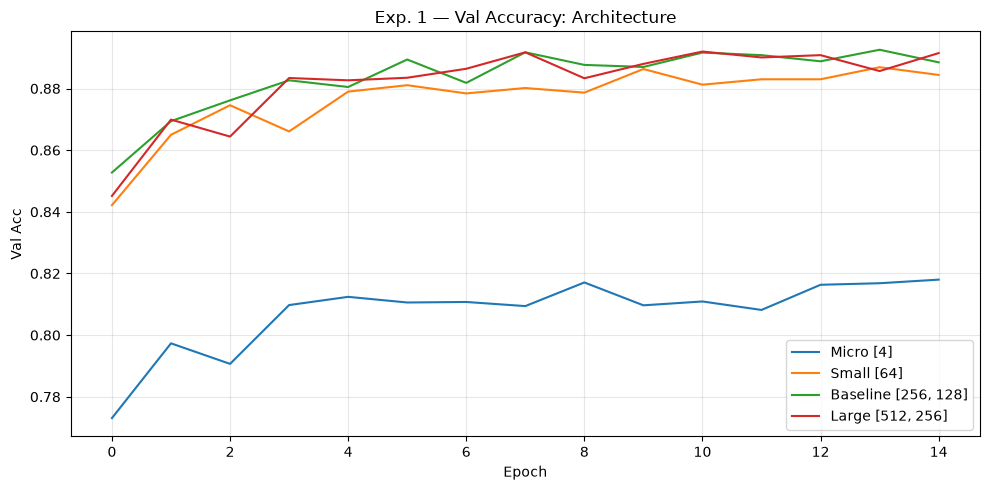

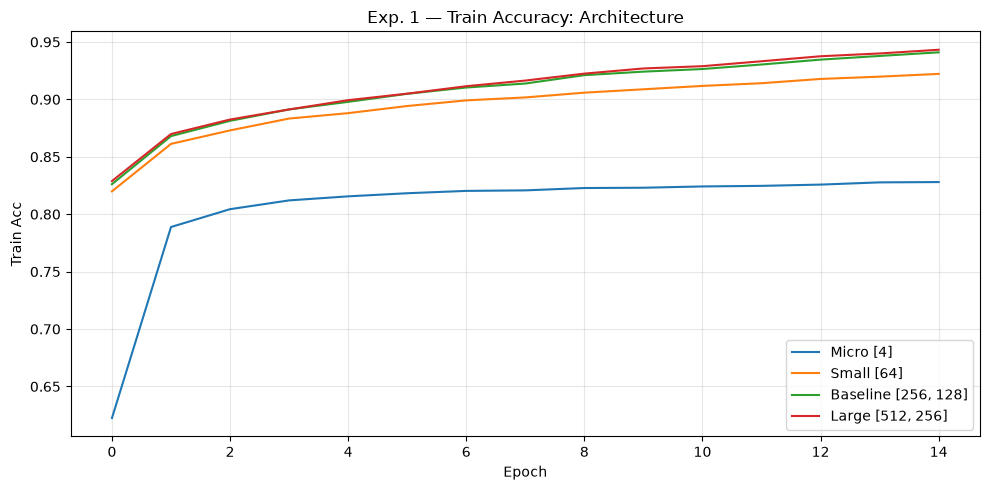

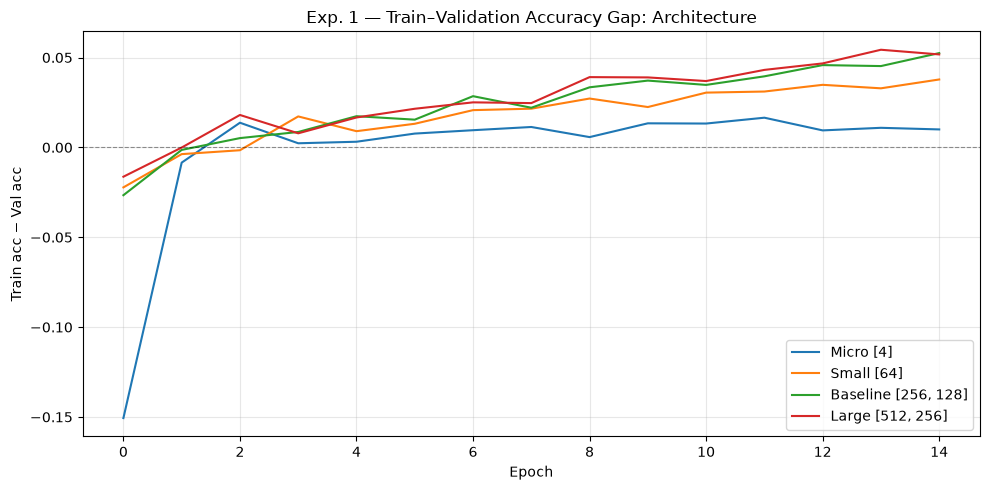

Config                     Train     Val     Gap    Test  Best val  @ epoch
Micro [4]                 82.80%  81.80%   1.00%  80.78%    81.80%       15
Small [64]                92.22%  88.44%   3.78%  87.75%    88.69%       14
Baseline [256, 128]       94.10%  88.85%   5.25%  88.02%    89.26%       14
Large [512, 256]          94.32%  89.15%   5.17%  88.78%    89.20%       11


In [15]:
# ── Experiment 1  Model Architecture ─────────────────────────────────────────
exp_1 = {}
test_1 = {}

configs_1 = {
    'Micro [4]': [4],
    'Small [64]': [64],
    'Baseline [256, 128]': [256, 128],
    'Large [512, 256]': [512, 256],
}

for name, sizes in configs_1.items():
    hist, test_acc = run_experiment(
        hidden_sizes=sizes,
        optimizer='adam',
        lr=1e-3,
        num_epochs=15,
        tag=name
    )
    exp_1[name] = hist
    test_1[name] = test_acc

plot_comparison(exp_1, metric='val_acc',   title='Exp. 1 — Val Accuracy: Architecture')
plot_comparison(exp_1, metric='train_acc', title='Exp. 1 — Train Accuracy: Architecture')
plot_gap(exp_1, title='Exp. 1 — Train–Validation Accuracy Gap: Architecture')
summary(exp_1, test_1)


**Results and Analysis** *(complete after running)*

Fill in the table from your results, then answer each observation:

| Config | Train acc (ep15) | Val acc (ep15) | Gap | Test acc |
|--------|-----------------|----------------|-----|----------|
| Micro [4] | 82.80% | 81.80% | 1.00 | 80.78% |
| Small [64] | 92.22% | 88.44% | 3.78 | 87.75% |
| Baseline [256, 128] | 94.10% | 88.85% | 5.25 | 88.02% |
| Large [512, 256] | 94.32% | 89.15% | 5.17 | 88.78% |

- **Underfitting**: Describe what you observe for Micro [4] in `train_acc` and `plot_gap`. Does a small gap always mean good generalisation? Why or why not?
- **Overfitting**: Which configurations show a clearly widening gap over 15 epochs? Describe the gap trajectory.
- **Val accuracy plateau**: At what capacity does validation accuracy begin to plateau? What does this suggest about the benefit of adding more model capacity under the current training setup?
- **Bias–variance trade-off**: Report the exact final-epoch gap for each configuration. Is the gap monotonically increasing with capacity?
- **Architecture selection**: Which architecture would you recommend? Justify your choice considering both val accuracy and gap — and note that Experiment 3 will address the overfitting you observed.

**Answers**

- **Underfitting:** Micro [4] stops improving at around 82% training accuracy after epoch 5 and its gap is only 1 point. A small gap does not mean the model generalises well here. Training and validation accuracy are both low because 4 neurons are not enough to learn the task. The gap is small only because the model cannot even fit the training data.
- **Overfitting:** Small, Baseline and Large all have a gap that grows over the 15 epochs. In the gap plot all curves start below zero at epoch 1 and then go up almost every epoch, reaching 3.78 for Small, 5.25 for Baseline and 5.17 for Large. Training accuracy keeps rising while validation accuracy is flat after about epoch 6 to 8.
- **Val accuracy plateau:** validation accuracy already reaches about 88.5% to 89% with Small [64]. Baseline and Large only add around 0.5 point even though they have about 4.6 and 10.5 times more parameters. The extra capacity mostly raises training accuracy, so adding more capacity does not help much with this setup.
- **Bias variance trade-off:** the final gaps are 1.00, 3.78, 5.25 and 5.17. The gap grows with size up to Baseline and then stays the same for Large, so it is not strictly monotonic.
- **Architecture selection:** we keep [256, 128]. It has the same validation accuracy as Large with less than half the parameters, and it is better than Micro and Small. Its gap of 5.25 is the problem we try to fix in Experiment 3.


### Experiment 2 — Optimiser and Learning Rate

Having selected an architecture in Experiment 1, the next step is to ensure training is efficient.

This experiment is split into two connected sub-experiments:

| Sub-experiment | Objective |
|----------------|-----------|
| **2.A — Learning rate** | Show that SGD is highly sensitive to LR — motivating the need for adaptive optimisers |
| **2.B — Optimiser comparison** | Verify that Adam addresses SGD's LR sensitivity and converges faster |

#### 2.A — Learning Rate

**Objective**: Demonstrate that SGD's performance depends critically on learning rate — and why this is a problem in practice.

**Setting**: architecture `[256, 128]`, SGD (no momentum), no regularisation, 15 epochs.  
**Vary**: LR ∈ {1e-5, 1e-3, 0.1}

| LR | Expected behaviour |
|----|--------------------|
| `1e-5` | Near-random accuracy — updates too small to move weights meaningfully |
| `1e-3` | Slow convergence — learning, but far from optimal within 15 epochs |
| `0.1` | Near-optimal — fast, stable convergence |


--------------------------------------------------
  SGD lr=1e-05
--------------------------------------------------


  Epoch  1: train=6.56%  val=6.87%


  Epoch  2: train=7.20%  val=7.58%


  Epoch  3: train=7.91%  val=8.42%


  Epoch  4: train=8.84%  val=9.33%


...

  Epoch 12: train=92.70%  val=88.56%


  Epoch 13: train=93.00%  val=88.38%


  Epoch 14: train=93.36%  val=88.73%


  Epoch 15: train=93.62%  val=88.15%


  Test accuracy: 87.74%


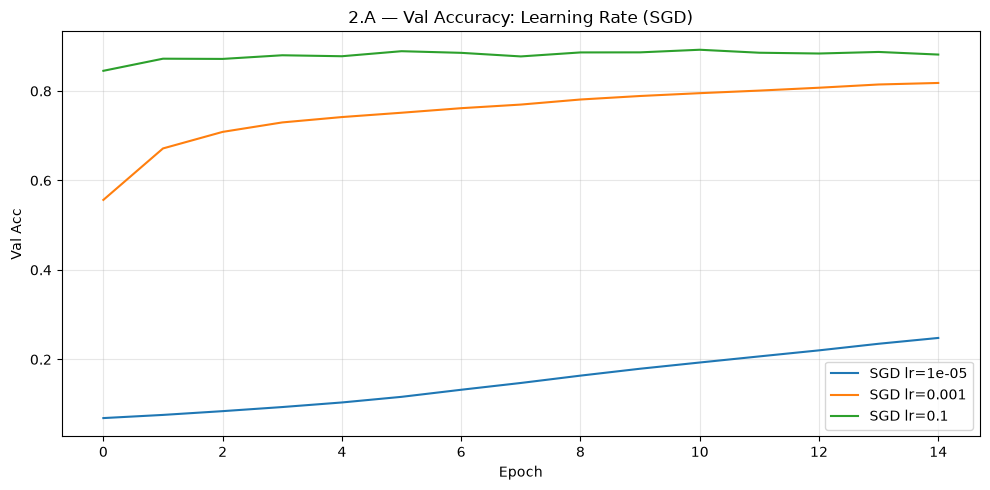

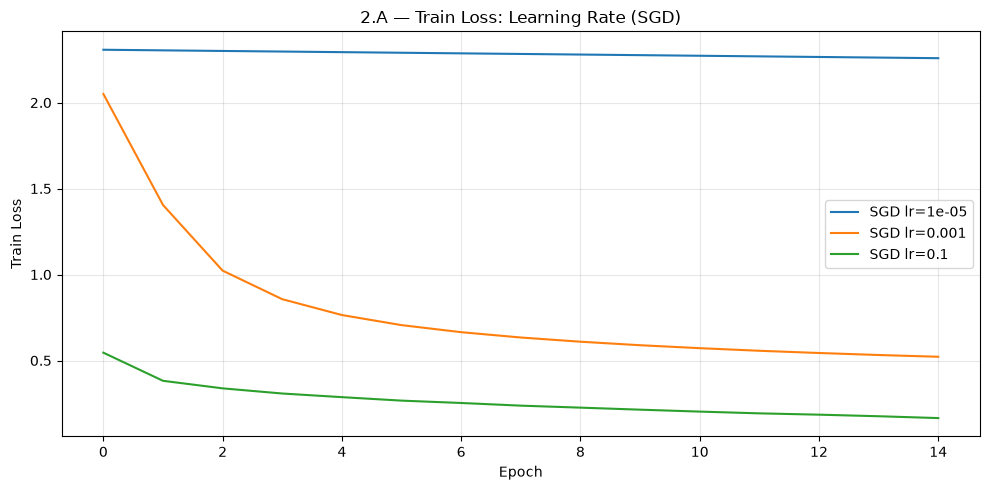

Config                     Train     Val     Gap    Test  Best val  @ epoch
SGD lr=1e-05              24.10%  24.78%  -0.68%  24.81%    24.78%       15
SGD lr=0.001              81.39%  81.80%  -0.41%  80.31%    81.80%       15
SGD lr=0.1                93.62%  88.15%   5.47%  87.74%    89.22%       11


In [16]:
# ── 2.A  Learning Rate ────────────────────────────────────────────────────────
exp_2a = {}
test_2a = {}

for lr in [1e-5, 1e-3, 0.1]:
    name = f'SGD lr={lr:g}'
    hist, test_acc = run_experiment(
        hidden_sizes=[256, 128],
        optimizer='sgd',
        lr=lr,
        num_epochs=15,
        tag=name
    )
    exp_2a[name] = hist
    test_2a[name] = test_acc

plot_comparison(exp_2a, metric='val_acc',    title='2.A — Val Accuracy: Learning Rate (SGD)')
plot_comparison(exp_2a, metric='train_loss', title='2.A — Train Loss: Learning Rate (SGD)')
summary(exp_2a, test_2a)


**Results and Analysis** *(complete after running)*

Report the final val accuracy and test accuracy for each LR configuration, then answer the questions below.

- Describe the convergence behaviour for each LR. What happens to a model trained with lr=1e-5 after 15 epochs?
- Compare lr=1e-3 and lr=0.1: both converge, but how differently? What does this say about the cost of a suboptimal LR choice?

| LR | Final val acc | Best val acc | Test acc |
|----|---------------|--------------|----------|
| 1e-5 | 24.78% | 24.78% (ep 15) | 24.81% |
| 1e-3 | 81.80% | 81.80% (ep 15) | 80.31% |
| 0.1 | 88.15% | 89.22% (ep 11) | 87.74% |

**Answers**

- With lr 1e-5 the model almost does not learn. Validation accuracy starts at 6.9% and only reaches 24.8% after 15 epochs, and the loss curve is almost flat. With SGD the update is the learning rate times the gradient, so with such a small value the weights barely move. With lr 1e-3 the model learns but slowly: 55.7% after the first epoch, 80% only at epoch 12 and 81.8% at the end, still going up and with no gap, so it has not converged yet. With lr 0.1 it is much faster: 84.5% after one epoch, 88% around epoch 4 and a best of 89.22% at epoch 11.
- For the same 15 epochs, lr 1e-3 ends 6.4 points below lr 0.1. So a bad learning rate with SGD costs a lot: either many more epochs or a worse model. In practice this means we have to try several learning rates, which takes many full trainings.


#### 2.B — Optimiser Comparison

**Objective**: Compare the convergence speed of SGD and Adam across the same range of learning rates — and determine whether Adam's adaptive mechanism provides a meaningful advantage.

**Setting**: architecture `[256, 128]`, no regularisation, **15 epochs**.

| Configuration | Optimiser | LR |
|---------------|-----------|-----|
| SGD — naive | SGD | `1e-3` |
| SGD — tuned | SGD | `0.1` |
| Adam — naive | Adam | `1e-3` |
| Adam lr=0.1 | Adam | `0.1` |
| Adam lr=1e-5 | Adam | `1e-5` |

**Focus on convergence speed** — how many epochs does each configuration need to reach 80%? 85%? 88% val accuracy?


--------------------------------------------------
  SGD lr=1e-3 (naive)
--------------------------------------------------


  Epoch  1: train=40.63%  val=62.65%


  Epoch  2: train=67.02%  val=69.57%


  Epoch  3: train=71.55%  val=71.92%


  Epoch  4: train=73.57%  val=74.31%


...

  Epoch 12: train=84.46%  val=84.25%


  Epoch 13: train=84.60%  val=84.53%


  Epoch 14: train=84.86%  val=84.47%


  Epoch 15: train=85.08%  val=84.92%


  Test accuracy: 83.56%


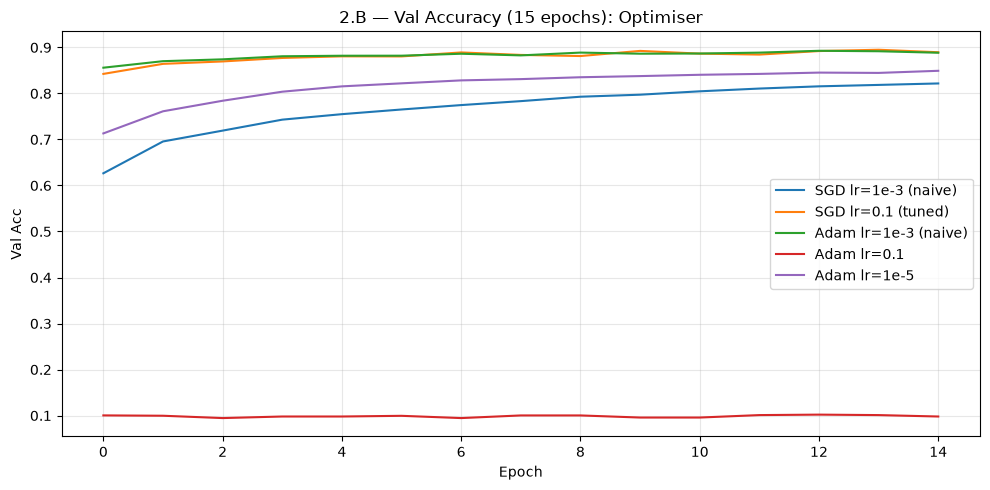

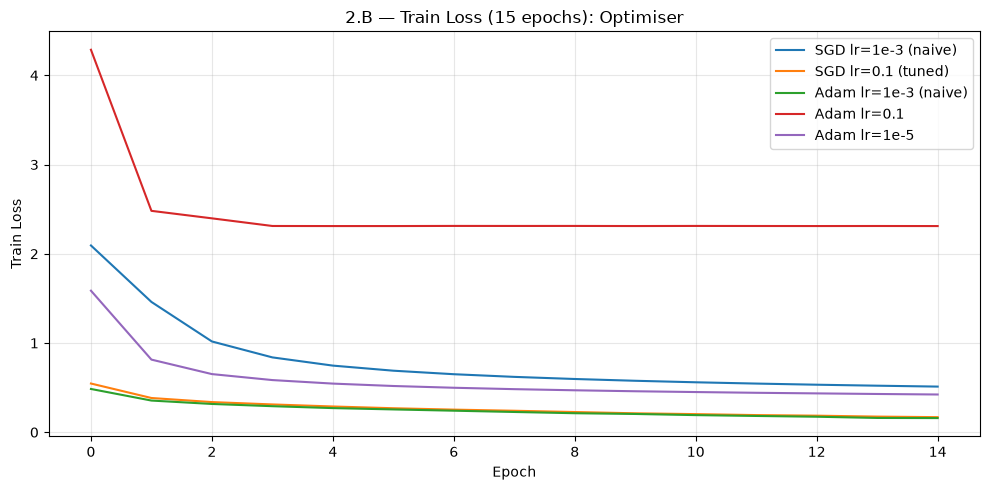

Config                     Train     Val     Gap    Test  Best val  @ epoch
SGD lr=1e-3 (naive)       81.96%  82.17%  -0.22%  81.05%    82.17%       15
SGD lr=0.1 (tuned)        93.64%  88.96%   4.68%  88.14%    89.50%       14
Adam lr=1e-3 (naive)      94.00%  88.85%   5.15%  88.48%    89.28%       13
Adam lr=0.1               10.09%   9.79%   0.30%  10.00%    10.20%       13
Adam lr=1e-5              85.08%  84.92%   0.16%  83.56%    84.92%       15

SGD lr=1e-3 (naive)      {0.8: 11, 0.85: None, 0.88: None}
SGD lr=0.1 (tuned)       {0.8: 1, 0.85: 2, 0.88: 5}
Adam lr=1e-3 (naive)     {0.8: 1, 0.85: 1, 0.88: 4}
Adam lr=0.1              {0.8: None, 0.85: None, 0.88: None}
Adam lr=1e-5             {0.8: 4, 0.85: None, 0.88: None}


In [17]:
# ── 2.B  Optimiser Comparison ─────────────────────────────────────────────────
# Compare SGD and Adam across the same LR values to show Adam's robustness
exp_2b = {}
test_2b = {}

configs_2b = [
    ('SGD lr=1e-3 (naive)',  'sgd',  1e-3),
    ('SGD lr=0.1 (tuned)',   'sgd',  0.1),
    ('Adam lr=1e-3 (naive)', 'adam', 1e-3),
    ('Adam lr=0.1',          'adam', 0.1),
    ('Adam lr=1e-5',         'adam', 1e-5),
]

for name, opt_name, lr in configs_2b:
    hist, test_acc = run_experiment(
        hidden_sizes=[256, 128],
        optimizer=opt_name,
        lr=lr,
        num_epochs=15,
        tag=name
    )
    exp_2b[name] = hist
    test_2b[name] = test_acc

plot_comparison(exp_2b, metric='val_acc',    title='2.B — Val Accuracy (15 epochs): Optimiser')
plot_comparison(exp_2b, metric='train_loss', title='2.B — Train Loss (15 epochs): Optimiser')
summary(exp_2b, test_2b)

print()
for name, hist in exp_2b.items():
    print(f'{name:<24}', {t: epochs_to_reach(hist, t) for t in [0.80, 0.85, 0.88]})


**Results and Analysis**

Fill in the convergence table from your results, then answer the questions below.

| Configuration | Learning Rate|Best val acc | Epochs to reach best |
|---------------|------------- |-------------|---------------------|
| SGD best| 0.1 | 89.50% | 14 |
| Adam best| 1e-3 | 89.28% | 13 |

- At which tested learning rate does each optimiser achieve its best validation accuracy?
- At each optimiser's best tested learning rate, compare their convergence speed. Does Adam converge noticeably faster than SGD? Relate your observation to Adam's adaptive parameter updates.
- At the same learning rate (lr=1e-3), compare the learning dynamics of SGD and Adam. What does this show about using the same global learning rate for different optimisers?

| Configuration | LR | Best val acc | Epochs to 85% | Epochs to 88% |
|---------------|----|--------------|---------------|---------------|
| SGD naive | 1e-3 | 82.17% | never | never |
| SGD tuned | 0.1 | 89.50% | 2 | 5 |
| Adam naive | 1e-3 | 89.28% | 1 | 4 |
| Adam | 0.1 | 10.20% | never | never |
| Adam | 1e-5 | 84.92% | never | never |

**Answers**

- SGD gets its best validation accuracy with lr 0.1 (89.50%) and Adam with lr 1e-3 (89.28%).
- At these best values Adam is a bit faster at the start: 85.6% after the first epoch against 84.3% for SGD, and it reaches 88% one epoch earlier. After that both end at about the same level. So once SGD is tuned, Adam is only slightly faster on this simple MLP. This is because Adam divides the step of each weight by the size of its recent gradients, so every weight gets a good step size from the start without tuning, and it also keeps a moving average of the gradients like momentum.
- At the same lr 1e-3 the two optimisers behave very differently. SGD only reaches 82.2% and needs 11 epochs to pass 80%, while Adam has 85.6% after one epoch and ends at 88.9%. The same number does not give the same step: for SGD the step depends on the size of the gradient, while for Adam it is roughly the learning rate for every weight. So a learning rate cannot be reused from one optimiser to another. Adam is also not good for any value: with lr 0.1 it stays at 10%, which is random guessing, because the steps are far too big. But with lr 1e-5 it still gets 84.9% while SGD only got 24.8%.


### Experiment 3 — Regularisation

**Objective**: In Experiment 1 you observed that `[256, 128]` shows a train–validation accuracy gap of ~4–5%. This experiment investigates techniques to reduce that gap without sacrificing validation accuracy.

**Setting**: architecture `[256, 128]`, Adam `lr=1e-3`, **20 epochs** (longer run makes overfitting dynamics clearly visible).

| Configuration | Parameters |
|---------------|-----------|
| Baseline | `dropout_rate=0.0, use_batchnorm=False` |
| Dropout | `dropout_rate=0.3` |
| Weight decay | `weight_decay=1e-3` in Adam |
| Dropout + BN | both enabled |

Plot `val_acc`, `train_acc`, and **`plot_gap`** — the gap plot directly shows which technique reduces overfitting most effectively.

> **Reminder**: A widening train–validation gap can indicate overfitting. Another common sign is that training performance continues to improve while validation performance stagnates or deteriorates.


--------------------------------------------------
  No regularisation
--------------------------------------------------


  Epoch  1: train=82.47%  val=86.29%


  Epoch  2: train=86.91%  val=87.67%


  Epoch  3: train=88.15%  val=87.60%


  Epoch  4: train=89.07%  val=86.99%


...

  Epoch 17: train=91.06%  val=89.40%


  Epoch 18: train=91.37%  val=89.40%


  Epoch 19: train=91.34%  val=89.33%


  Epoch 20: train=91.63%  val=89.19%


  Test accuracy: 89.03%


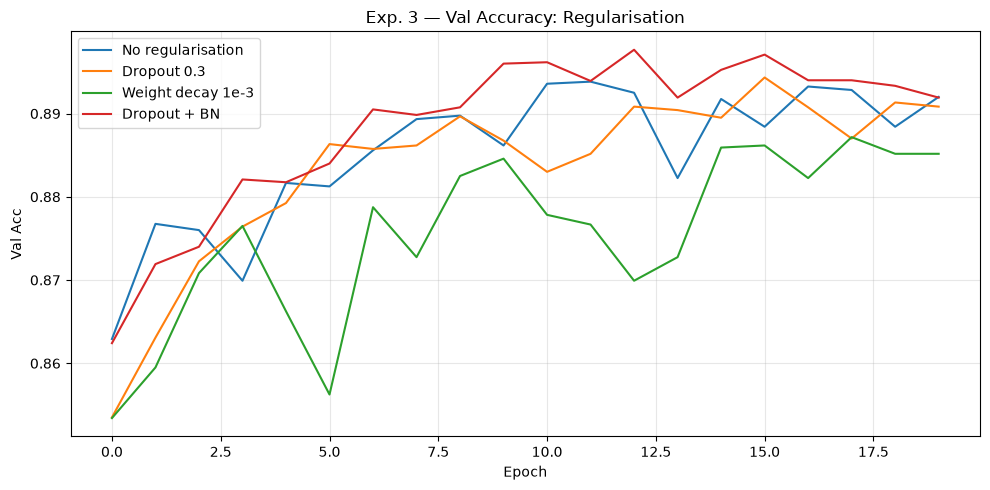

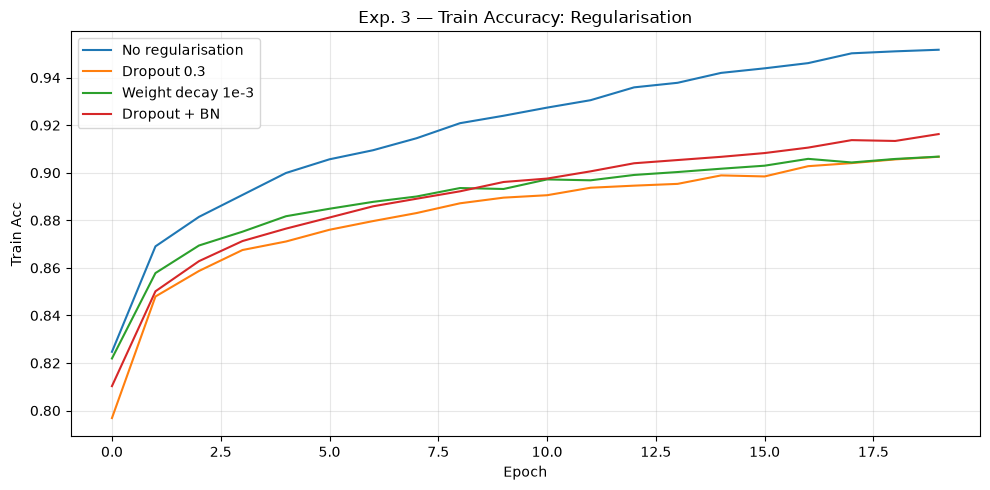

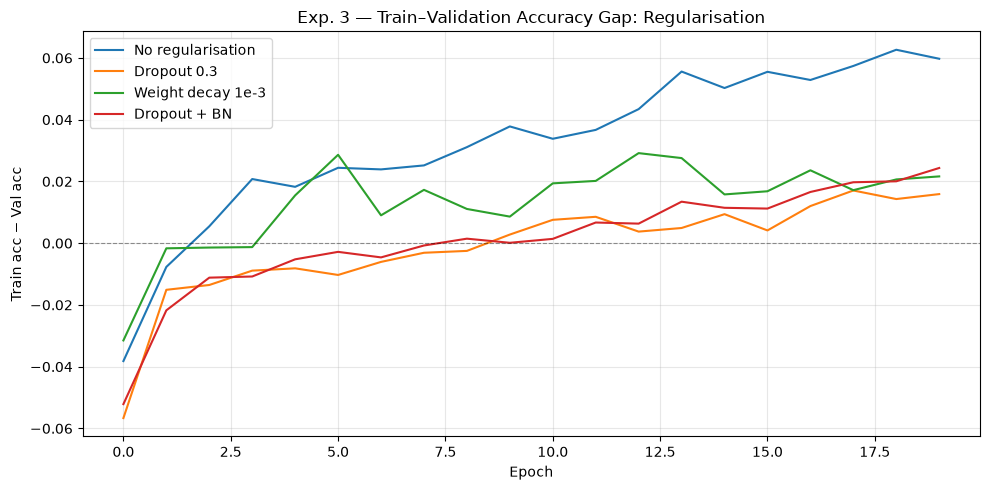

Config                     Train     Val     Gap    Test  Best val  @ epoch
No regularisation         95.17%  89.20%   5.97%  88.12%    89.38%       12
Dropout 0.3               90.67%  89.08%   1.59%  88.64%    89.43%       16
Weight decay 1e-3         90.68%  88.52%   2.16%  87.65%    88.72%       18
Dropout + BN              91.63%  89.19%   2.44%  89.03%    89.77%       13


In [18]:
# ── Experiment 3  Regularisation ─────────────────────────────────────────────
exp_3 = {}
test_3 = {}
N_EPOCHS = 20

configs_3 = [
    ('No regularisation', dict()),
    ('Dropout 0.3',       dict(dropout_rate=0.3)),
    ('Weight decay 1e-3', dict(weight_decay=1e-3)),
    ('Dropout + BN',      dict(dropout_rate=0.3, use_batchnorm=True)),
]

for name, extra in configs_3:
    hist, test_acc = run_experiment(
        hidden_sizes=[256, 128],
        optimizer='adam',
        lr=1e-3,
        num_epochs=N_EPOCHS,
        tag=name,
        **extra
    )
    exp_3[name] = hist
    test_3[name] = test_acc

plot_comparison(exp_3, metric='val_acc',   title='Exp. 3 — Val Accuracy: Regularisation')
plot_comparison(exp_3, metric='train_acc', title='Exp. 3 — Train Accuracy: Regularisation')
plot_gap(exp_3, title='Exp. 3 — Train–Validation Accuracy Gap: Regularisation')
summary(exp_3, test_3)


**Results and Analysis** *(complete after running)*

Report train accuracy, validation accuracy, and train–validation accuracy gap for each configuration in a table and answer the questions below:

| Configuration | Train (ep20) | Val (ep20) | Gap | Test acc | Epoch of best val acc |
|---------------|-------------|-----------|-----|----------|------------------|
| No regularisation | 95.17% | 89.20% | 5.97 | 88.12% | 12 |
| Dropout 0.3 | 90.67% | 89.08% | 1.59 | 88.64% | 16 |
| Weight decay 1e-3 | 90.68% | 88.52% | 2.16 | 87.65% | 18 |
| Dropout + BN | 91.63% | 89.19% | 2.44 | 89.03% | 13 |

- Dropout and weight decay both can reduce overfitting but through different mechanisms. Explain each. Which configuration shows the smallest train–validation accuracy gap and highest validation accuracy? 
- Looking at the *Epoch of best val acc* column: how does adding regularisation affect the number of epochs the model needs to reach its best val accuracy? What does this tell you about the relationship between regularisation and training dynamics?
- Play with the hyperparameters, and document your observations. (Optional)

**Answers**

- Dropout randomly turns off 30% of the hidden neurons at each training step, so the network cannot depend on a few neurons and has to learn more robust features. It is turned off during evaluation. Weight decay adds a penalty on the squared weights to the loss, which keeps the weights small and gives a smoother function that memorises less noise. Dropout 0.3 gives the smallest gap, 1.59 points compared to 5.97 without regularisation. Dropout with batch norm gives the highest validation accuracy during training (89.77%) and the best test accuracy (89.03%) with a small gap of 2.44. The final validation accuracy is actually close for no regularisation, dropout and dropout with batch norm (89.1% to 89.2%), so the main effect of regularisation here is to stop training accuracy from going too high (95.2% down to about 91%). Weight decay 1e-3 also reduces the gap, but its validation curve is less stable (it drops to 85.6% at epoch 6) and it ends with the lowest scores, so 1e-3 is probably too strong.
- Without regularisation the best validation accuracy comes at epoch 12, and after that only training accuracy improves. With dropout (epoch 16) and weight decay (epoch 18) the best epoch comes later. Training is harder with regularisation, so the model learns more slowly, but validation keeps improving for more epochs. Dropout with batch norm peaks at epoch 13, earlier than dropout alone, because batch norm makes training faster and more stable. So regularisation slows down convergence but makes the extra epochs useful. Without it we would need to stop training early, around epoch 12.
- Optional part: not done.
